In [1]:
import pandas as pd

In [8]:
#df=pd.read_csv("European_Bank.csv")
df=pd.read_csv("../../data/raw/European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df['CustomerId'].duplicated().sum()
#no duplicate record by customerid 

0

In [9]:
df.duplicated().sum()
#no duplicate rows present 

0

In [10]:
#converting customerid,surname,geography,gender to string dtype
df['CustomerId'] = df['CustomerId'].astype(str)
df['Surname'] = df['Surname'].astype(str)
df['Geography'] = df['Geography'].astype(str)
df['Gender'] = df['Gender'].astype(str)


In [12]:
#converting year,creditscore,age,tenure,numofproducts,balance,estsalary to numerics 
for col in ['Year', 'CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'Balance','EstimatedSalary']:
                df[col] = pd.to_numeric(df[col], errors='coerce')


In [14]:
df['IsActiveMember'].dtype

dtype('int64')

In [15]:
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

for col in binary_cols:
    df[col] = df[col].astype(int)

In [16]:
df['IsActiveMember'].dtype #downscaled the datatype size

dtype('int32')

In [17]:
df.describe()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# #ANALYSED FACTS!
# 1. AGE RANGE 18 TO 92 / 38 MEAN
# 2. AVG TENURE THE CUSTOMER PREFER IS 5 , MAX GOES TO 10 YRS 
# 3. MAX BALANCE/ACC IS $250898.090000 , AVG ACTBALANCE AMT $76485.889288
# 4. MIN PRODUCT RANGE FROM 1 TO MAX 4 . 
# 70% HAS CARD 
# 50% IS ACTIVEMEMBER
# 20% EXCITED 
# estimatesalary of customer (11.580000	,199992.480000	) avg:100090.239881
# *** 25% of customers have 0 balance
# **** year column can be dropped 
    


In [25]:
# *** 25% of customers have 0 balance
# **** year column can be dropped 
zero_balance=(df['Balance']==0).mean()*100
print(zero_balance)
#36.17% of accounts have zero balance     

36.17


In [19]:
(df['Balance'] >= 0).all()
#balance in theacc for each case is valid 

True

In [21]:
df['HasCrCard'].isin([0,1]).all()
#no invalid values are there for hascard bool feild

True

In [22]:
df['IsActiveMember'].isin([0,1]).all()
#no invalid values are there for isactivemem bool feild

True

In [23]:
df['Exited'].isin([0,1]).all()
#no invalid values are there for Exited bool feild

True

In [26]:
df = df.dropna()  

In [27]:
df = df.drop(columns=['Year'])

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [29]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Age', ylabel='Count'>

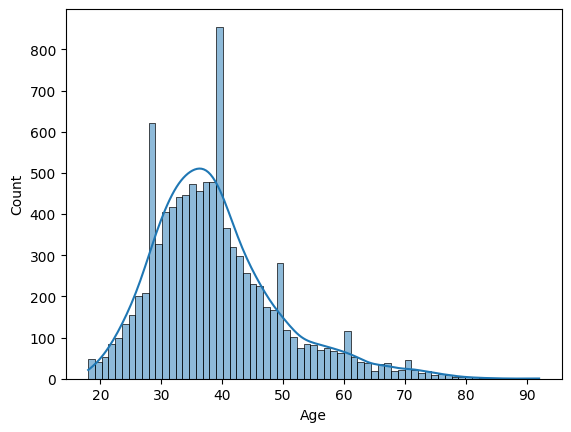

In [32]:
sns.histplot(df['Age'], kde=True)

In [ ]:
#age 30 to 45 max contributed 
#peak at 40 age 
#old people seems depressive in investment 
#age 28 , 40 , 50 act like a outlier 


<Axes: xlabel='CreditScore', ylabel='Count'>

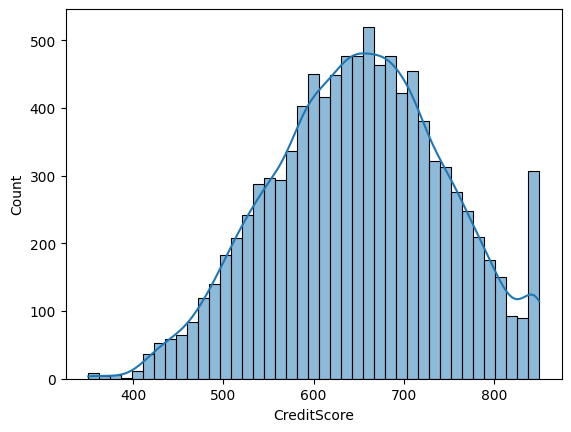

In [33]:
sns.histplot(df['CreditScore'], kde=True)

In [ ]:
#credit card score seems max probslistic value between 600 to 700 #peak 650 
#there are maximum no of customers with creditscore bw 650 
#scroe range(400,850 estimated)
#spike at 850 seems unrealistic like outlier *****(why this occurs??)

<Axes: xlabel='NumOfProducts', ylabel='count'>

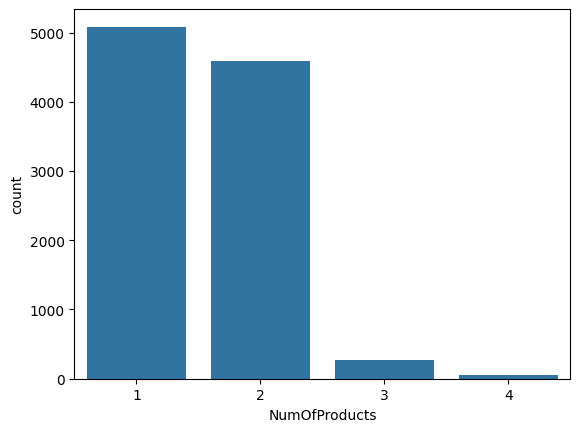

In [34]:
sns.countplot(x='NumOfProducts', data=df)

In [ ]:
# #there are 
# 5000 customer-->1 product 
# 4500 customer-->2 products
# 200 customer -->3 products
# 50 customer -->4 product 
# range 1 to 4 


<Axes: xlabel='Tenure', ylabel='Count'>

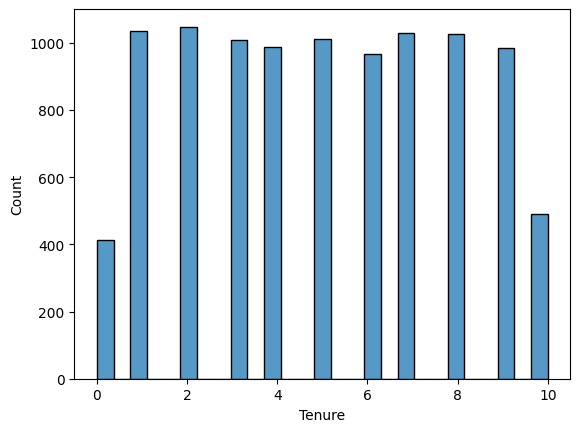

In [35]:
sns.histplot(df['Tenure'])

<Axes: xlabel='Tenure', ylabel='Count'>

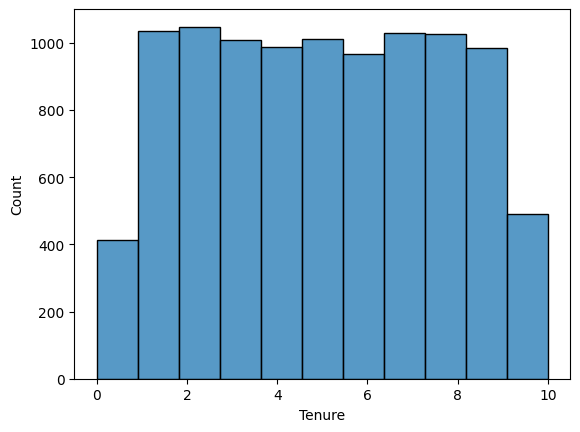

In [36]:
sns.histplot(data=df,x='Tenure',bins=11)

In [ ]:
#2,7,8 are max prefered tenure 
#tenure 0 means brand new customer ,the customer has not completed the first month but they have product 

<Axes: xlabel='Balance', ylabel='Count'>

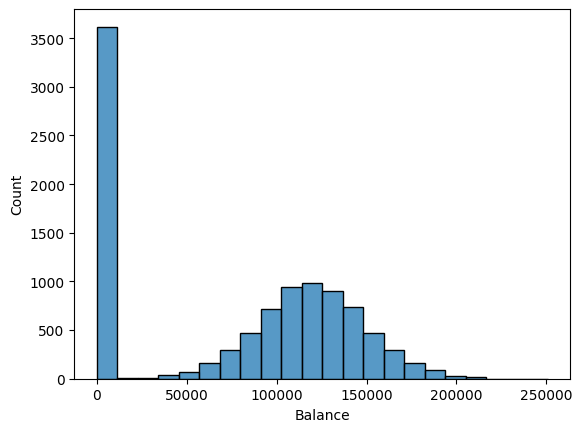

In [37]:
sns.histplot(df['Balance'])

<Axes: xlabel='Geography', ylabel='Count'>

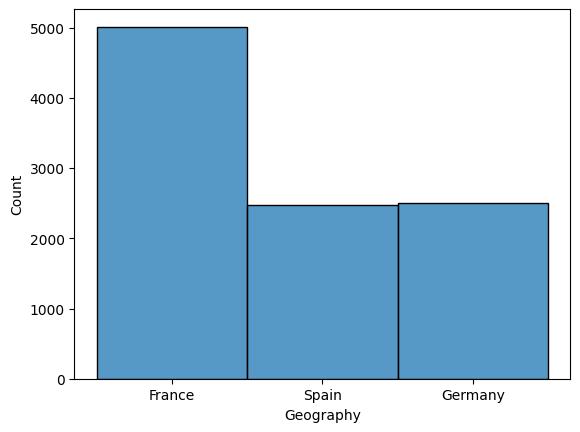

In [52]:
sns.histplot(df['Geography'])

<Axes: xlabel='Gender', ylabel='Count'>

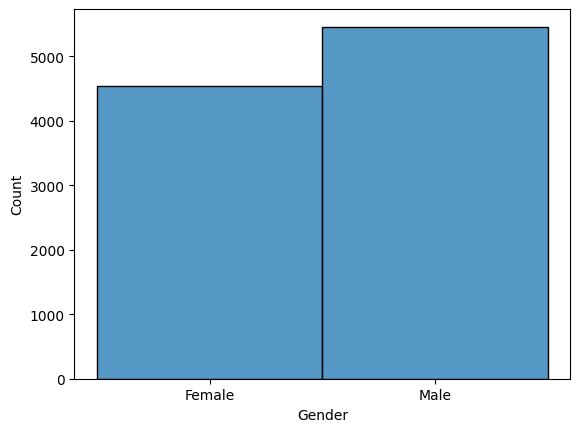

In [53]:
sns.histplot(df['Gender'])

In [ ]:
#over 3500(37% ) of customer have 0 balance 
#this is poor case::: INACTIVE ACCOUNTS OR NON USERS EXISTANCE 

#maximal customer balance THRIVE TO -->125000$
#range:50000$ to 200000

#A URGENT NEED 
# A SPLIT OF DATA SEGMENTATION "ACTIVE VS INACTIVE" 

In [38]:
df.groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [ ]:
#ACTIVE MEMBER HAS HIGHER RETENTION THAN NONACTIVE 
# Active → lower churn
# Inactive → higher churn

In [39]:
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [ ]:
#customer with 4 product--> 0% retention rate "high probability of leaving " but why? 
#cutomer with 3 product -->17% retention rate 
#customer with 2 product --->92% retention rate , "high probability of staying n invest more ,loyalty exist"
#cutomr with 1 product--->72.29 % retention rate ,"27% churn "

#2>1>3>4

#2 products → lower churn (sweet spot)

In [40]:
df.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [ ]:
#the customer who exit had higher balance amt $91108.539337 


#customer with high amt balance are more likely to leave/churn ****

In [43]:
df[(df['IsActiveMember'] == 0) & (df['NumOfProducts'] > 2)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
30,15589475,Azikiwe,591,Spain,Female,39,3,0.00,3,1,0,140469.38,1
70,15703793,Konovalova,738,Germany,Male,58,2,133745.44,4,1,0,28373.86,1
88,15622897,Sharpe,646,France,Female,46,4,0.00,3,1,0,93251.42,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9554,15593778,Craig,779,France,Female,29,3,46388.16,3,1,0,127939.26,1
9613,15737025,Roberts,635,France,Male,33,1,0.00,3,0,0,178067.33,1
9737,15741197,Calzada,710,Spain,Male,22,8,0.00,3,1,0,107292.91,0
9747,15775761,Iweobiegbunam,610,Germany,Female,69,5,86038.21,3,0,0,192743.06,1


In [44]:
df[(df['Exited'] == 1) & (df['IsActiveMember'] == 1)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
46,15602280,Martin,829,Germany,Female,27,9,112045.67,1,1,1,119708.21,1
47,15771573,Okagbue,637,Germany,Female,39,9,137843.80,1,1,1,117622.80,1
90,15757535,Heap,647,Spain,Female,44,5,0.00,3,1,1,174205.22,1
104,15804919,Dunbabin,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,15774586,West,692,Germany,Female,43,10,118588.83,1,1,1,161241.65,1
9947,15732202,Abramovich,615,France,Male,34,1,83503.11,2,1,1,73124.53,1
9960,15681026,Lucciano,795,Germany,Female,33,9,104552.72,1,1,1,120853.83,1
9981,15672754,Burbidge,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1


In [45]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [ ]:
#out of total customer 20 % exit n 80% are live 

In [47]:
df1 = df[(df['IsActiveMember'] == 0) & (df['NumOfProducts'] > 2)]
df2 = df[(df['Exited'] == 1) & (df['IsActiveMember'] == 1)]

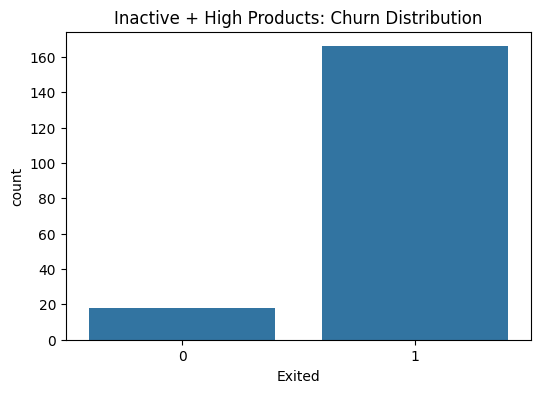

In [49]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df1)
plt.title("Inactive + High Products: Churn Distribution")
plt.show()

In [51]:
df.to_csv("datafinance_v1.1.csv", index=False)

In [ ]:
.ipynb 


In [ ]:
#spike at 850 seems unrealistic like outlier *****(why this occurs??)
#customer with 4 product are having 100% probability of customer churn ???
#customer with high amt balance leave the bank, high customer churn rate ???

In [ ]:
# 1. Why is there a massive spike at a Credit Score of 850? (The "Outlier" Spike)In banking datasets (like the famous Churn Modeling dataset), a sharp spike at the absolute maximum value ($850$) is almost never a natural distribution. It happens due to Ceiling Effects / Data Clipping.

In [ ]:
# 2. Why do customers with 4 products have a 100% churn rate?
# It seems impossible that people who bought 4 products from a bank would all leave, but this is a classic symptom of Product Stuffing or Forced Cross-Selling.

# Aggressive Sales Tactics: Often, relationship managers under heavy sales pressure "stuff" products onto a customer (e.g., opening secondary savings accounts, unnecessary credit cards, or dormant mutual fund portfolios) to hit quotas.

# The Friction Point: When a customer realizes they are being charged maintenance fees for 4 different accounts/products they didn't really want, they get frustrated, close all accounts, and completely churn.

# The "Systemic" Flag: In banking, having 3 or 4 products without an active membership flag is often a trailing indicator that the customer has already initiated a multi-product closure sequence.

In [ ]:
# 3. Why do high-balance customers leave the bank?You noted that the average churned balance is $\$91,108$, while the overall average is $\$76,485$. This is a massive issue called Wealth Flight.Lack of Competitive Yield: High-net-worth individuals do not leave money sitting idle in low-interest checking accounts. If your bank is only offering basic products, they will move their $\$91\text{k}+$ balance to wealth management firms, high-yield certificates of deposit (CDs), or brokerage accounts.Service Dissatisfaction: High-balance customers expect premium service. If they are treated like a regular customer with zero-balance, they take their significant capital elsewhere. They are highly sensitive to fee structures

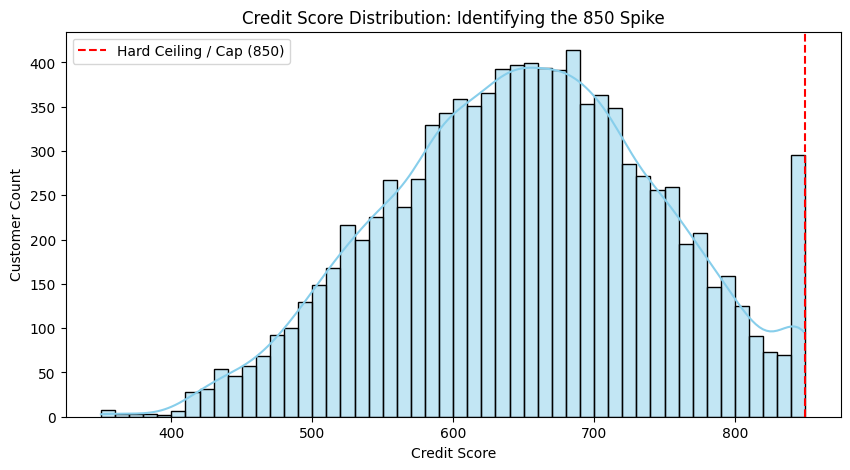

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, x="CreditScore", bins=50, kde=True, color="skyblue"
)
plt.axvline(
    850, color="red", linestyle="--", label="Hard Ceiling / Cap (850)"
)
plt.title("Credit Score Distribution: Identifying the 850 Spike")
plt.xlabel("Credit Score")
plt.ylabel("Customer Count")
plt.legend()
plt.show()

C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_30592\2043974999.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_30592\2043974999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


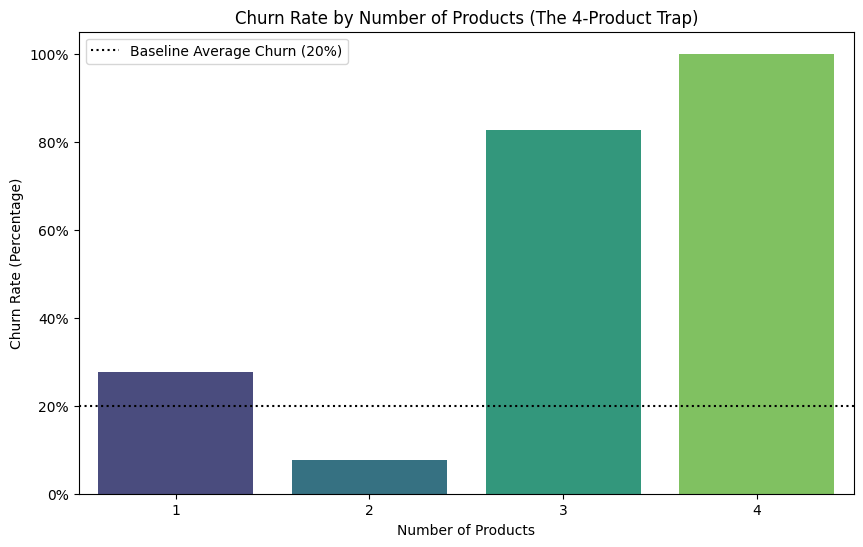

In [55]:
plt.figure(figsize=(10, 6))
# Assuming 'Exited' or 'Churn' is your target variable (1 = Churn, 0 = Retained)
# Replace 'Exited' with your actual target column name
sns.barplot(
    data=df, x="NumOfProducts", y="Exited", ci=None, palette="viridis"
)
plt.axhline(
    0.20,
    color="black",
    linestyle=":",
    label="Baseline Average Churn (20%)",
)
plt.title("Churn Rate by Number of Products (The 4-Product Trap)")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (Percentage)")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: "{:.0%}".format(y))
)
plt.legend()
plt.show()

C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_30592\1698102822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Exited", y="Balance", palette="Set2")


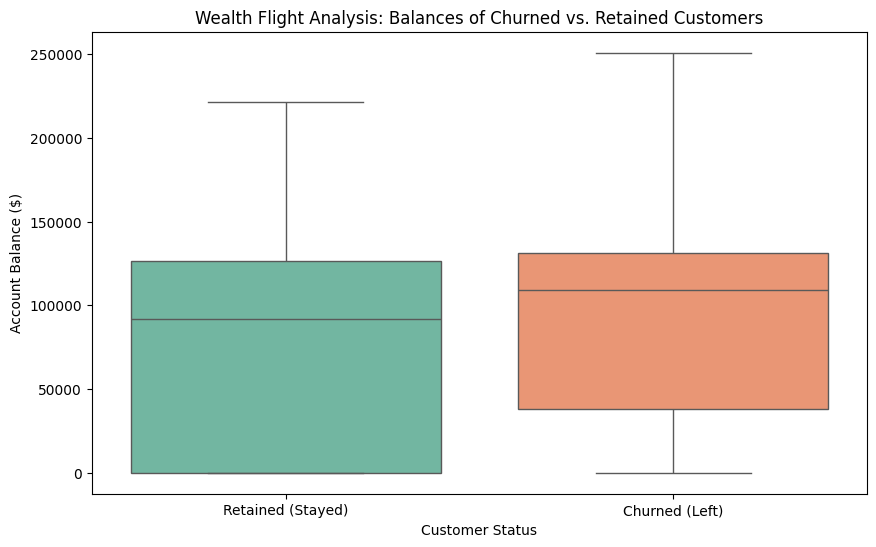

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Exited", y="Balance", palette="Set2")
plt.xticks([0, 1], ["Retained (Stayed)", "Churned (Left)"])
plt.title("Wealth Flight Analysis: Balances of Churned vs. Retained Customers")
plt.xlabel("Customer Status")
plt.ylabel("Account Balance ($)")
plt.show()